In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 3** — Drug Discovery (3D)
- I am working on a drug discovery project, testing combinations of three compounds to create a new medicine. 
    - The goal is to maximise the efficiency of the drug, which is represented by an output value where higher is better (closer to 0). 
    - This is a 3D search space where the relationship between compound ratios and efficacy is unknown.

- **Optimisation Goal**: Maximise (closer to 0 = better)

- **Input**: 3D array (Three compound concentrations).

- **All-time best**: -0.003713 at [0.374538, 0.449618, 0.445819] (Week 7)

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 3
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_3/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_3/initial_outputs.npy')

# New data for Week 9 (Function 3)
X_w9_new_point = np.array([0.399995, 0.499225, 0.459658], dtype=np.float64)
Y_w9_new_point = np.array([-0.025490845982412275], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w9_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w9_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_3/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_3/initial_outputs.npy', Y_updated)

print("Updated Inputs (X) - Function 3: ", X_unique)
print("Updated Outputs (Y) - Function 3: ", Y_updated)

Updated Inputs (X) - Function 3:  [[4.68089497e-02 2.31360241e-01 7.70617592e-01]
 [1.34621666e-01 2.19917240e-01 4.58206220e-01]
 [1.51836632e-01 4.39990619e-01 9.90881867e-01]
 [1.70476994e-01 6.97032401e-01 1.49169434e-01]
 [1.71525207e-01 3.43916870e-01 2.48737201e-01]
 [2.20549337e-01 2.97825244e-01 3.43555344e-01]
 [2.42114461e-01 6.44074270e-01 2.72432809e-01]
 [3.07095000e-01 2.91699000e-01 4.62318000e-01]
 [3.42299000e-01 3.41527000e-01 4.71230000e-01]
 [3.45523271e-01 9.41359831e-01 2.69363479e-01]
 [3.74538000e-01 4.49618000e-01 4.45819000e-01]
 [3.99995000e-01 4.99225000e-01 4.59658000e-01]
 [4.92581415e-01 6.11593188e-01 3.40176386e-01]
 [5.34905720e-01 3.98500915e-01 1.73388729e-01]
 [6.00097282e-01 7.25135725e-01 6.60886415e-02]
 [6.45502835e-01 3.97142940e-01 9.19771338e-01]
 [6.66013659e-01 6.71985151e-01 2.46295297e-01]
 [7.46911945e-01 2.84196309e-01 2.26299855e-01]
 [9.06930000e-01 1.42503000e-01 5.04446000e-01]
 [9.09286000e-01 9.74205000e-01 4.75969000e-01]
 [9.65

## **Output Analysis**

- **Comparison**: Week 9 returned -0.0255. 
    - While this is a strong result compared to the initial data, it is significantly lower than my Week 7/8 peak of -0.0037.

- **Real-world Implication**: Moving slightly right and up in the compound ratios from our best point caused a sharp drop in efficacy. 
    - This suggests the peak is very narrow and sensitive to specific concentration balances.

- **Model/Future Exploration**: The Gaussian Process now sees that the Week 7 peak is likely the center of the active zone. 
    - For Week 10, I need to pivot back toward those Week 7 coordinates but explore the immediate vicinity in the opposite direction of the Week 9 query to see if the peak continues there.

## **Bayesian Optimization**

- **Changes**: I am using the Yeo-Johnson Output Transformation and a Matern 2.5 kernel.

- **Reasoning**: In drug discovery, one compound often has a much more sensitive trigger than the others. 
    - By allowing the length scales to be flexible, the GP can learn which of the 3 compounds is the most critical for stability.
    - The Yeo-Johnson transform is used to handle the negative nature of the data.

In [3]:
# Yeo-Johnson Output Transformation
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

# Matern kernel - allowing for different sensitivities across the 3 compounds
kernel = Matern(length_scale=[0.1, 0.1, 0.1], length_scale_bounds=(1e-2, 1.0), nu=2.5) + \
         WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20)
model.fit(X_unique, Y_transformed)

/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**

- **Strategy:** Expected Improvement (EI) with $\xi$ tightened to 0.0003.

- **Reasoning:** We are within the final decimal places of zero — the theoretical ideal score. At this stage, asking for even a tiny improvement over -0.003712 is the correct move. Any exploration of new regions would be a waste of a query when the confirmed peak is this well localised.

- **Key Changes:** 
    - $\xi$ tightened from 0.0005 to **0.0003** — maximum exploitation.
    - Focused grid **re-centred on the W8 all-time best [0.375, 0.450, 0.446]** with std=**0.010** (tighter than W9's 0.015).
    - **90/10** focused-to-uniform split — the final stages of lead optimisation.

- **Intended Impact:** Return to and surpass the W8 best of -0.003712, pushing the adverse reaction score as close to zero as possible.

In [5]:
def expected_improvement(X, model, y_max, xi=0.0003):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1)
    mu = mu.reshape(-1, 1)
    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Re-center on W8 all-time best — W9 regression confirms this is the correct target
w8_best = np.array([0.374538, 0.449618, 0.445819])

# 90% Focused, 10% Uniform — maximum exploitation
X_focused = np.random.normal(loc=w8_best, scale=0.010, size=(9000, 3))
X_uniform = np.random.uniform(0, 1, size=(1000, 3))
X_candidates = np.clip(np.vstack([X_focused, X_uniform]), 0, 1)

y_max = np.max(Y_transformed)
ei_values = expected_improvement(X_candidates, model, y_max, xi=0.0003)
next_query = X_candidates[np.argmax(ei_values)]

print(f'W8 best coordinates: {w8_best}')
print(f'Strategic Week 10 Query (Function 3): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}')

W8 best coordinates: [0.374538 0.449618 0.445819]
Strategic Week 10 Query (Function 3): 0.546887-0.128536-0.420137


## **Visualisation**

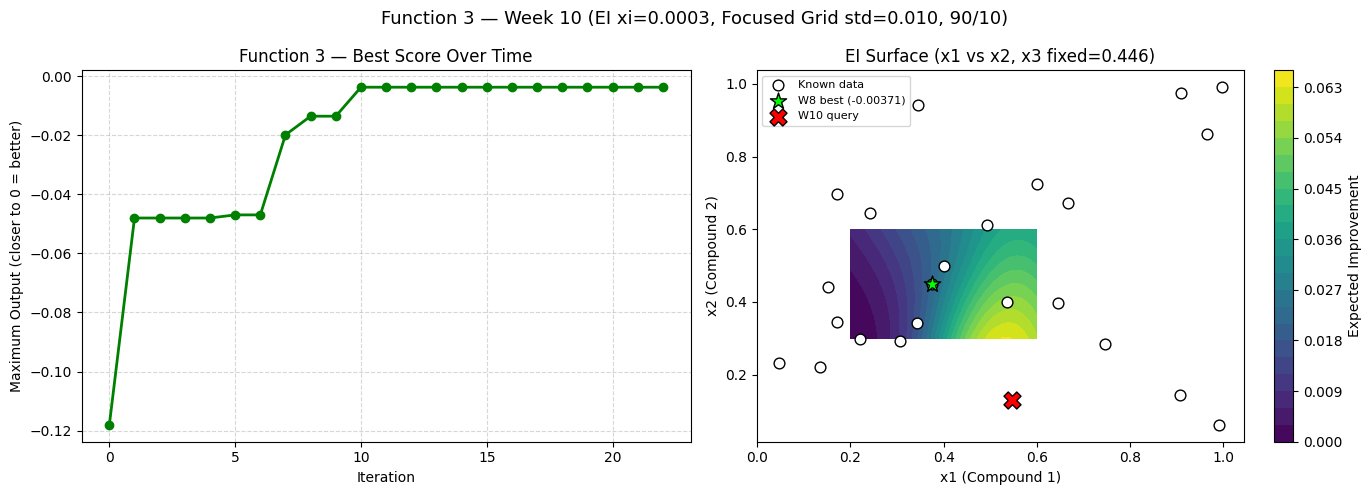

In [6]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(running_max, marker='o', color='green', linewidth=2)
axes[0].set_title('Function 3 — Best Score Over Time')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Maximum Output (closer to 0 = better)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# EI slice: x1 vs x2, x3 fixed at W8 best
res = 80
x1_r = np.linspace(0.2, 0.6, res)
x2_r = np.linspace(0.3, 0.6, res)
X1, X2 = np.meshgrid(x1_r, x2_r)
X_slice = np.column_stack([X1.ravel(), X2.ravel(), np.full(res*res, w8_best[2])])
ei_slice = expected_improvement(X_slice, model, y_max, xi=0.0003).reshape(res, res)

sc = axes[1].contourf(X1, X2, ei_slice, levels=20, cmap='viridis')
plt.colorbar(sc, ax=axes[1], label='Expected Improvement')
axes[1].scatter(X_unique[:, 0], X_unique[:, 1],
                c='white', edgecolors='black', s=60, zorder=5, label='Known data')
axes[1].scatter(w8_best[0], w8_best[1],
                c='lime', edgecolors='black', s=150, marker='*', zorder=6, label='W8 best (-0.00371)')
axes[1].scatter(next_query[0], next_query[1],
                c='red', edgecolors='black', s=150, marker='X', zorder=7, label='W10 query')
axes[1].set_title(f'EI Surface (x1 vs x2, x3 fixed={w8_best[2]:.3f})')
axes[1].set_xlabel('x1 (Compound 1)')
axes[1].set_ylabel('x2 (Compound 2)')
axes[1].legend(fontsize=8)

plt.suptitle('Function 3 — Week 10 (EI xi=0.0003, Focused Grid std=0.010, 90/10)', fontsize=13)
plt.tight_layout()
plt.show()